In [9]:
import numpy as np
import pandas as pd
import matplotlib
from matplotlib import pyplot as plt
import statsmodels.api as sm
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import datetime
from statsmodels.tsa.stattools import adfuller, kpss

import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

import pmdarima
from pmdarima import ARIMA
from pmdarima import auto_arima


In [11]:
data_full = pd.read_csv("merged_data.csv")
data_full.set_index('time',inplace=True)
data_full.index = pd.to_datetime(data_full.index)
data_full.head(3)

,ESP motor Current - phase A,ESP motor Current - phase B,ESP motor Current - phase C,VSD power frequency,ESP motor temperature,ESP differential pressure,ESP intake Pressure,Water Cut @ 20degC/1 atm,ESP intake temperature,ESP discharge pressure,...,extValues_ESP discharge pressure,extValues_ESP discharge temperature sensor,extValues_Choke Opening,extValues_Well head pressure,extValues_Well aligned to Train A,extValues_Well aligned to Train B,extValues_ESP Motor Voltage,extValues_ESP Vibration X,extValues_ESP Vibration Y,extValues_Well head Temperature
time,,,,,,,,,,,,,,,,,,,,,
2011-12-26 21:00:00+00:00,63.0,66.94,64.0,40.08,NaN,118.51,147.69,0.7,77.48,229.39,...,60.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2011-12-26 22:00:00+00:00,64.0,67.00,64.0,39.99,NaN,116.11,144.47,0.7,78.37,224.55,...,41.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2011-12-26 23:00:00+00:00,64.0,67.00,64.0,40.08,NaN,114.61,142.83,0.7,78.58,221.84,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [3]:
data_full.drop(data_full[data_full['VSD power frequency'] < 7].index,inplace=True)
data_full.drop(data_full[pd.isna(data_full['VSD power frequency'])].index,inplace=True)

In [5]:
pd.isna(data_full['VSD power frequency'])

time
2011-12-26 21:00:00+00:00    False
2011-12-26 22:00:00+00:00    False
2011-12-26 23:00:00+00:00    False
2011-12-27 00:00:00+00:00    False
2011-12-27 01:00:00+00:00    False
                             ...  
2017-05-24 08:00:00+00:00    False
2017-05-24 09:00:00+00:00    False
2017-05-24 10:00:00+00:00    False
2017-06-03 18:00:00+00:00    False
2017-06-03 20:00:00+00:00    False
Name: VSD power frequency, Length: 590508, dtype: bool

In [13]:
# Checking some variables

#data_name = 'Well head pressure'
for data_name in data_full.columns:
    data = data_full[data_full['Well Run'] ==well[0]][data_name]
    indsort = np.argsort(data)
    data_size = data.size
    
    #loc = np.concatenate((indsort[:int(data_size*5/100)],indsort[int(data_size*95/100):]))

#data.drop(data.iloc[loc].index,inplace=True)


#plt.plot(data)
#plt.figure()
#plt.plot(d1_data)
#plt.figure()
#plt.plot(d2_data)
    try:
        data = data.dropna()
        res = adfuller(data,autolag='AIC')
    except:
        continue

    
    print(f'{data_name}\n ADF: {res[0]:.2e}\n p-value: {res[1]:.4f}\n')

ESP motor Current - phase A
 ADF: -3.38e+00
 p-value: 0.0118

ESP motor Current - phase B
 ADF: -3.33e+00
 p-value: 0.0137

ESP motor Current - phase C
 ADF: -3.76e+00
 p-value: 0.0034

VSD power frequency
 ADF: -2.25e+00
 p-value: 0.1892

ESP motor temperature
 ADF: -8.92e+00
 p-value: 0.0000

ESP differential pressure
 ADF: -1.33e+00
 p-value: 0.6131

ESP intake Pressure
 ADF: 1.62e+00
 p-value: 0.9979

Water Cut @ 20degC/1 atm
 ADF: -2.14e+00
 p-value: 0.2305

ESP intake temperature
 ADF: -4.13e+00
 p-value: 0.0009

ESP discharge pressure
 ADF: -4.39e+00
 p-value: 0.0003

Choke Opening
 ADF: -3.25e+00
 p-value: 0.0174

Well head pressure
 ADF: -3.52e+00
 p-value: 0.0074

Well head Temperature
 ADF: -9.98e+00
 p-value: 0.0000

Well aligned to Train A
 ADF: -1.88e+00
 p-value: 0.3431

Well aligned to Train B
 ADF: -1.70e+00
 p-value: 0.4309

ESP Motor Voltage
 ADF: -1.09e+00
 p-value: 0.7173

ESP Vibration X
 ADF: -1.74e+00
 p-value: 0.4096

ESP Vibration Y
 ADF: -1.18e+00
 p-value: 0

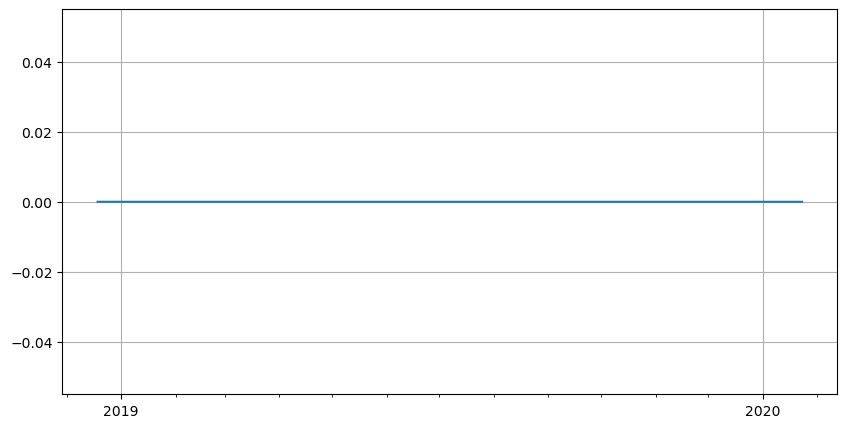

In [161]:
# Plot all data

import os
import matplotlib.dates as mdates

if not os.path.isdir('Figures'):
    os.mkdir('Figures')

well_ids = np.unique(data_full['Well Run'])

fig = plt.figure()

locator = mdates.MonthLocator()
month_fmt = mdates.DateFormatter('')
locatory = mdates.YearLocator()
year_fmt = mdates.DateFormatter('%Y')

fig.set_size_inches(10,5)
for data_name in data_full.columns:

    dir_name = data_name

    for i in range(len(dir_name)):
        if dir_name[i] == '@':
            dir_name = dir_name[:i] + 'At' + dir_name[i+1:]

        if dir_name[i] == '/':
            dir_name = dir_name[:i] + dir_name[i+1:]
    
    if not os.path.isdir(f'Figures/{dir_name}'):
        os.mkdir(f'Figures/{dir_name}')
        
        for well in well_ids:
            data = data_full[data_full['Well Run'] == well][data_name]
            data = data.dropna()
    
            plt.clf()
            plt.plot(data)
            ax = plt.gca()
            ax.xaxis.set_major_locator(locatory)
            ax.xaxis.set_major_formatter(year_fmt)
            ax.xaxis.set_minor_locator(locator)
            ax.xaxis.set_minor_formatter(month_fmt)
            plt.grid(True)
            plt.savefig(f'Figures/{dir_name}/{well}')
        

In [142]:
data.index

DatetimeIndex(['2015-11-13 19:00:00+00:00', '2015-11-13 20:00:00+00:00',
               '2015-11-13 21:00:00+00:00', '2015-11-13 22:00:00+00:00',
               '2015-11-13 23:00:00+00:00', '2015-11-14 00:00:00+00:00',
               '2015-11-14 02:00:00+00:00', '2015-11-14 03:00:00+00:00',
               '2015-11-14 04:00:00+00:00', '2015-11-14 05:00:00+00:00',
               ...
               '2020-02-17 03:00:00+00:00', '2020-02-17 04:00:00+00:00',
               '2020-02-18 02:00:00+00:00', '2020-02-18 04:00:00+00:00',
               '2020-02-25 03:00:00+00:00', '2020-02-25 11:00:00+00:00',
               '2020-02-28 17:00:00+00:00', '2020-04-07 06:00:00+00:00',
               '2020-04-07 15:00:00+00:00', '2020-04-07 16:00:00+00:00'],
              dtype='datetime64[ns, UTC]', name='time', length=17001, freq=None)

In [107]:
pvals = pd.DataFrame(index = np.unique(data_full['Well Run']),
                    columns = data_full.columns)

pvals.drop('Well Run',axis=1)

for well_name in pvals.index:
    for data_name in pvals.columns:
        try:
            data = data_full[data_full['Well Run'] == well_name][data_name]
            data_size = data.size
            data = data.dropna()
            res = adfuller(data,autolag='AIC')
            pvals.loc[well_name,data_name] = res[1]
        except:
            continue
    


pvals

/home/epic-heitor/anaconda3/lib/python3.11/site-packages/statsmodels/regression/linear_model.py:956: RuntimeWarning: divide by zero encountered in log
  llf = -nobs2*np.log(2*np.pi) - nobs2*np.log(ssr / nobs) - nobs2
/home/epic-heitor/anaconda3/lib/python3.11/site-packages/statsmodels/regression/linear_model.py:956: RuntimeWarning: divide by zero encountered in log
  llf = -nobs2*np.log(2*np.pi) - nobs2*np.log(ssr / nobs) - nobs2
/home/epic-heitor/anaconda3/lib/python3.11/site-packages/statsmodels/regression/linear_model.py:956: RuntimeWarning: divide by zero encountered in log
  llf = -nobs2*np.log(2*np.pi) - nobs2*np.log(ssr / nobs) - nobs2
/home/epic-heitor/anaconda3/lib/python3.11/site-packages/statsmodels/regression/linear_model.py:956: RuntimeWarning: divide by zero encountered in log
  llf = -nobs2*np.log(2*np.pi) - nobs2*np.log(ssr / nobs) - nobs2
/home/epic-heitor/anaconda3/lib/python3.11/site-packages/statsmodels/regression/linear_model.py:956: RuntimeWarning: divide by zero 

,ESP motor Current - phase A,ESP motor Current - phase B,ESP motor Current - phase C,VSD power frequency,ESP motor temperature,ESP differential pressure,ESP intake Pressure,Water Cut @ 20degC/1 atm,ESP intake temperature,ESP discharge pressure,...,extValues_ESP discharge pressure,extValues_ESP discharge temperature sensor,extValues_Choke Opening,extValues_Well head pressure,extValues_Well aligned to Train A,extValues_Well aligned to Train B,extValues_ESP Motor Voltage,extValues_ESP Vibration X,extValues_ESP Vibration Y,extValues_Well head Temperature
A-03 1,0.132179,0.16205,0.146224,0.03892,0.967575,0.44421,0.214629,0.366177,0.0,0.012802,...,0.00048,NaN,0.0,0.0,NaN,NaN,0.000001,0.0,0.0,0.0
A-03 2,0.050436,0.03057,0.0092,0.000022,0.000019,0.830134,0.082613,0.895069,0.000234,0.716841,...,0.036848,NaN,0.0,0.006617,NaN,NaN,0.134815,0.000168,0.966651,0.465604
A-04 1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000001,0.0,0.0,...,0.000009,NaN,0.0,0.000012,NaN,NaN,0.0,0.0,0.0,0.0
A-06 1,0.065897,0.061167,0.087612,0.006888,0.070786,0.022069,0.105263,NaN,0.002638,0.627492,...,0.268316,NaN,NaN,0.0,NaN,NaN,0.307746,0.289849,0.239705,0.0
A-06 2,0.0,0.0,0.0,0.0,0.002209,0.892813,0.0,NaN,0.005078,0.001005,...,0.0,NaN,0.0,0.0,NaN,NaN,0.0,0.0,0.0,0.0
A-08 1,0.000249,0.000028,0.0,0.000003,0.0,0.0,NaN,0.023489,0.334435,0.000016,...,0.0,NaN,0.000037,0.0,NaN,NaN,0.0,0.0,0.0,0.0
A-08 2,0.0,0.0,0.0,0.0,0.000004,0.0,0.000003,0.40379,0.0,0.005544,...,0.0,NaN,0.0,0.0,NaN,NaN,0.0,0.0,0.001245,0.000003
A-09 1,0.002091,0.001017,0.000748,0.0,0.000013,0.002866,0.000001,0.00029,0.0,0.0,...,0.0,NaN,0.0,0.004207,NaN,NaN,0.0,0.0,0.000002,0.000001
A-09 2,0.0,0.0,0.0,0.0,0.0,0.000169,0.000615,0.096108,0.0,0.000544,...,0.0,NaN,0.0,0.000001,NaN,NaN,0.0,0.0,0.0,0.0
A-10 1,0.210231,0.138348,0.158879,0.37701,0.021255,0.872843,0.000016,0.096871,0.0,0.133184,...,0.0,NaN,0.000001,0.0,NaN,NaN,0.0,0.0,0.0,0.0


In [ ]:
# Getting well ids

well_ids = np.unique(data_full['Well Run'])

well = np.random.choice(well_ids,1,replace=False)

print(well)

In [774]:
data_name = 'ESP motor Current - phase A'

well = ['A-23 1']

# Checking some variables


data = data_full[data_full['Well Run'] ==well[0]][data_name]
indsort = np.argsort(data)
data_size = data.size
data = data.dropna()

res = adfuller(data,autolag='AIC')
print(res[1])


res = kpss(data)
print(res[1])

3.2829649863331096e-11
0.01


/tmp/ipykernel_73360/3702852930.py:17: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  res = kpss(data)


['A-08 2']
3.3900590154931863e-10


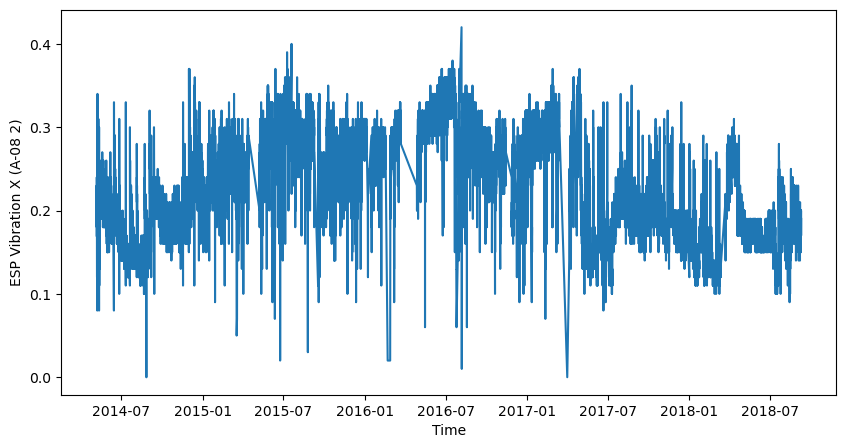

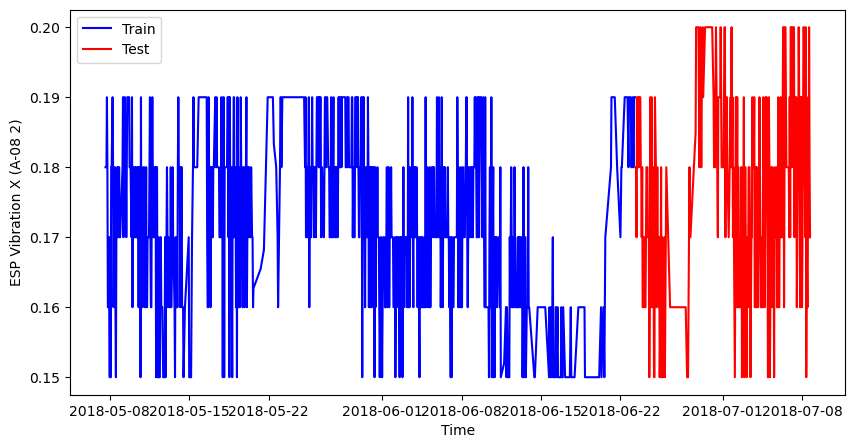

In [65]:
# Getting well ids

data_name = 'ESP Vibration X'
well_ids = np.unique(data_full['Well Run'])
#well_ids = pvals[pvals[data_name]>0.05].index

well = np.random.choice(well_ids,1,replace=False)
well = ['A-08 2']

print(well)
#print(pvals.loc[well,data_name])

# Checking some variables


data = data_full[data_full['Well Run'] ==well[0]][data_name]
indsort = np.argsort(data)
data_size = data.size
data = data.dropna()

#data = data.resample('D').mean().interpolate()

end = 2*30*24 

data_train = data.iloc[-(2*30*24)-end:-(15*24)-end]
data_test = data.iloc[-(15*24)-end:-end]

mn = data_train.mean()
st = data_train.std()*1

data_train[data_train>mn+st] = np.nan
data_train[data_train<mn-st] = np.nan
data_train.interpolate(method='linear', limit_area='inside',inplace=True)


mn = data_test.mean()
st = data_test.std()*1
data_test[data_test>mn+st] = np.nan
data_test[data_test<mn-st] = np.nan
data_test.interpolate(method='linear', limit_area='inside',inplace=True)

res = adfuller(data,autolag='AIC')
print(res[1])
    #loc = np.concatenate((indsort[:int(data_size*5/100)],indsort[int(data_size*95/100):]))

#data.drop(data.iloc[loc].index,inplace=True)

d1_data = np.diff(data_train)
d2_data = np.diff(d1_data)

#plt.plot(data_full[data_full['Well Run'] ==well[0]]['Water Cut @ 20degC/1 atm'])
#plt.figure()
plt.plot(data)
plt.gcf().set_size_inches(10,5)
plt.xlabel("Time")
plt.ylabel(f'{data_name} ({well[0]})')
plt.figure()
plt.plot(data_train,'b-')
plt.plot(data_test,'r-')

plt.gcf().set_size_inches(10,5)
plt.xlabel("Time")
plt.ylabel(f'{data_name} ({well[0]})')

plt.legend(['Train', 'Test'])
#plt.figure()
#plt.plot(d2_data)

In [109]:
pvals.to_csv("pvals.csv",index=True)

In [92]:
from statsmodels.tsa.stattools import adfuller

res = adfuller(data,autolag='AIC')

print(res)

(0.5472385198265978, 0.9862403127846554, 35, 7168, {'1%': -3.4312626176538585, '5%': -2.8619433051702137, '10%': -2.5669846752065544}, -75319.70960142714)


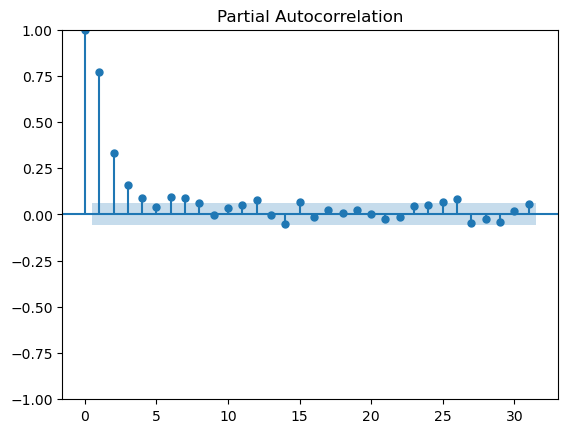

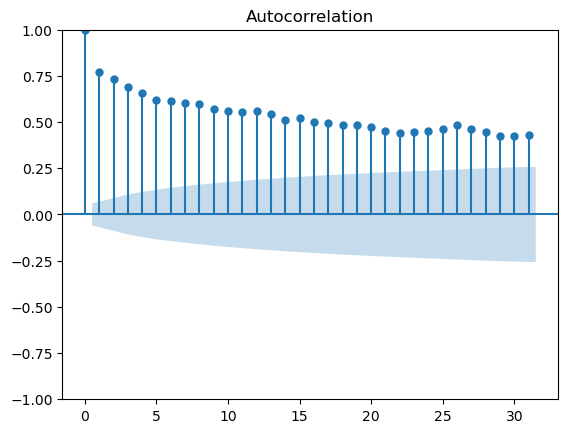

In [713]:
# data, d1_data
plot_pacf(data_train);
plot_acf(data_train);


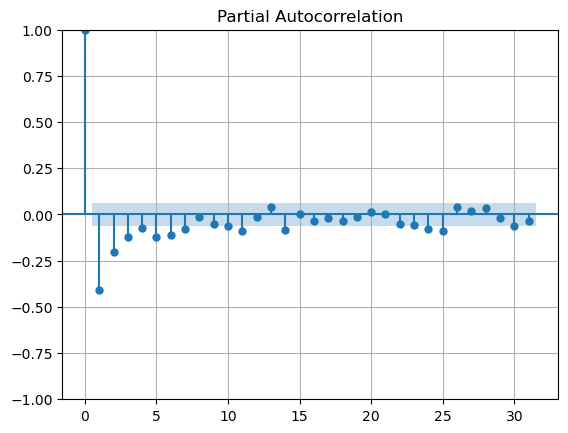

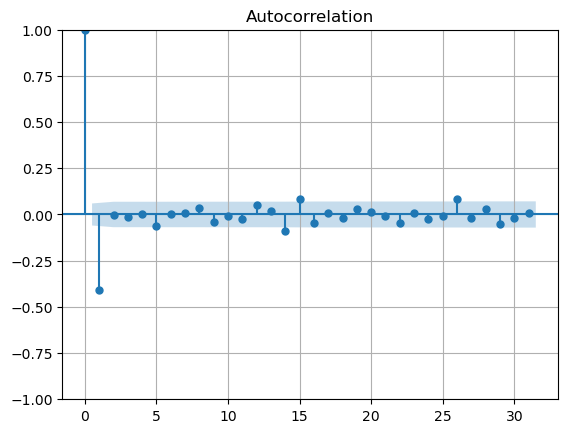

In [698]:
# data, d1_data
plot_pacf(d1_data);
plt.grid(True)
plot_acf(d1_data);
plt.grid(True)

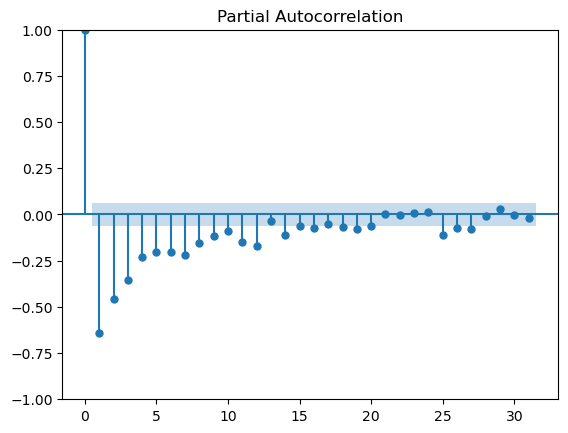

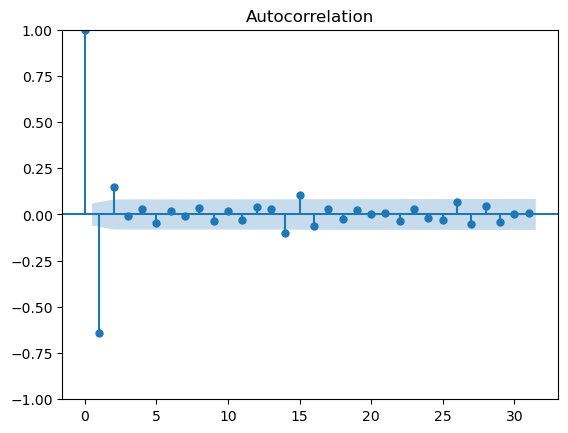

In [712]:
plot_pacf(d2_data);
plot_acf(d2_data);


In [48]:
sm.stats.diagnostic.acorr_ljungbox(data,boxpierce=True)

,lb_stat,lb_pvalue,bp_stat,bp_pvalue
1,8639.206058,0.0,8636.208415,0.0
2,17271.620116,0.0,17264.628759,0.0
3,25897.241902,0.0,25885.262329,0.0
4,34516.073361,0.0,34498.112643,0.0
5,43128.116440,0.0,43103.183214,0.0
6,51733.373085,0.0,51700.477558,0.0
7,60331.845244,0.0,60289.999190,0.0
8,68923.534864,0.0,68871.751626,0.0
9,77508.443894,0.0,77445.738381,0.0
10,86086.574284,0.0,86011.962969,0.0


In [674]:
model = auto_arima(
            y                 = data_train,
            d                 = 1,
            max_p             = 40,
            max_q             = 40,
            seasonal          = False,
            test              = 'adf',
            trace             = True,
            error_action      = 'ignore',
            stepwise          = True
        )

res = model
model.summary()

Performing stepwise search to minimize aic
 ARIMA(2,1,2)(0,0,0)[0] intercept   : AIC=3244.217, Time=1.35 sec
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=3661.522, Time=0.04 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=3420.222, Time=0.13 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=3267.060, Time=0.28 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=3659.522, Time=0.03 sec
 ARIMA(1,1,2)(0,0,0)[0] intercept   : AIC=3242.262, Time=1.68 sec
 ARIMA(0,1,2)(0,0,0)[0] intercept   : AIC=3259.073, Time=0.35 sec
 ARIMA(1,1,1)(0,0,0)[0] intercept   : AIC=3255.596, Time=0.56 sec
 ARIMA(1,1,3)(0,0,0)[0] intercept   : AIC=3244.221, Time=1.44 sec
 ARIMA(0,1,3)(0,0,0)[0] intercept   : AIC=3252.095, Time=0.50 sec
 ARIMA(2,1,1)(0,0,0)[0] intercept   : AIC=3246.240, Time=0.58 sec
 ARIMA(2,1,3)(0,0,0)[0] intercept   : AIC=3245.076, Time=1.92 sec
 ARIMA(1,1,2)(0,0,0)[0]             : AIC=3240.500, Time=0.45 sec
 ARIMA(0,1,2)(0,0,0)[0]             : AIC=3257.115, Time=0.18 sec
 ARIMA(1,1,1)(0,0,0)[0]          

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                      y   No. Observations:                 1080
Model:               SARIMAX(1, 1, 2)   Log Likelihood               -1616.250
Date:                Thu, 05 Sep 2024   AIC                           3240.500
Time:                        15:53:46   BIC                           3260.435
Sample:                             0   HQIC                          3248.049
                               - 1080                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.7890      0.054     14.565      0.000       0.683       0.895
ma.L1         -1.4789      0.059    -24.899      0.000      -1.595      -1.362
ma.L2          0.5019      0.052      9.630      0.000       0.400       0.604
sigma2         1.1698      0.016     72.941      0.000       1.138       1.201
===================================================================================
Ljung-Box (L1) (Q):                   0.01   Jarque-Bera (JB):             16246.41
Prob(Q):                              0.93   Prob(JB):                         0.00
Heteroskedasticity (H):               1.44   Skew:                            -2.63
Prob(H) (two-sided):                  0.00   Kurtosis:                        21.27
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [670]:
res = model
model.summary()


<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                      y   No. Observations:                 1080
Model:               SARIMAX(2, 0, 1)   Log Likelihood               -1629.962
Date:                Thu, 05 Sep 2024   AIC                           3267.925
Time:                        15:52:17   BIC                           3287.863
Sample:                             0   HQIC                          3275.474
                               - 1080                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          1.1704      0.026     45.827      0.000       1.120       1.220
ar.L2         -0.1704      0.026     -6.671      0.000      -0.220      -0.120
ma.L1         -0.8400      0.019    -43.158      0.000      -0.878      -0.802
sigma2         1.1874      0.017     70.982      0.000       1.155       1.220
===================================================================================
Ljung-Box (L1) (Q):                   0.25   Jarque-Bera (JB):             16176.58
Prob(Q):                              0.62   Prob(JB):                         0.00
Heteroskedasticity (H):               1.44   Skew:                            -2.63
Prob(H) (two-sided):                  0.00   Kurtosis:                        21.22
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [724]:
# pmdarima
import pmdarima
from pmdarima import ARIMA

ord = (25,1,1)
seas_ord=(0,0,0,0)

mod = ARIMA(order=ord,seasonal_order=seas_ord,enforce_stationarity=False,enforce_invertibility=False)
#mod = sm.tsa.SARIMAX(endog=sim,order=(1,0,1),trend='c').fit(disp=0)
res = mod.fit(data_train,disp=0)
res.summary()

/home/epic-heitor/anaconda3/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/home/epic-heitor/anaconda3/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                      y   No. Observations:                 1080
Model:              SARIMAX(25, 1, 1)   Log Likelihood               -1249.480
Date:                Fri, 06 Sep 2024   AIC                           2554.960
Time:                        10:43:22   BIC                           2693.850
Sample:                             0   HQIC                          2607.613
                               - 1080                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
intercept      0.0099      0.036      0.273      0.785      -0.061       0.081
ar.L1         -0.8783      0.303     -2.901      0.004      -1.472      -0.285
ar.L2         -0.5373      0.177     -3.029      0.002      -0.885      -0.190
ar.L3         -0.3767      0.118     -3.200      0.001      -0.607      -0.146
ar.L4         -0.3146      0.091     -3.460      0.001      -0.493      -0.136
ar.L5         -0.3391      0.086     -3.959      0.000      -0.507      -0.171
ar.L6         -0.3093      0.090     -3.441      0.001      -0.485      -0.133
ar.L7         -0.2412      0.085     -2.846      0.004      -0.407      -0.075
ar.L8         -0.1763      0.078     -2.261      0.024      -0.329      -0.023
ar.L9         -0.1947      0.067     -2.892      0.004      -0.327      -0.063
ar.L10        -0.2038      0.073     -2.795      0.005      -0.347      -0.061
ar.L11        -0.1899      0.067     -2.853      0.004      -0.320      -0.059
ar.L12        -0.1002      0.062     -1.617      0.106      -0.222       0.021
ar.L13        -0.0734      0.050     -1.470      0.142      -0.171       0.024
ar.L14        -0.1587      0.047     -3.376      0.001      -0.251      -0.067
ar.L15        -0.1125      0.060     -1.880      0.060      -0.230       0.005
ar.L16        -0.1201      0.052     -2.289      0.022      -0.223      -0.017
ar.L17        -0.1139      0.058     -1.980      0.048      -0.227      -0.001
ar.L18        -0.1164      0.055     -2.131      0.033      -0.223      -0.009
ar.L19        -0.0937      0.054     -1.732      0.083      -0.200       0.012
ar.L20        -0.0764      0.057     -1.345      0.179      -0.188       0.035
ar.L21        -0.0998      0.055     -1.809      0.070      -0.208       0.008
ar.L22        -0.1591      0.052     -3.067      0.002      -0.261      -0.057
ar.L23        -0.1702      0.054     -3.139      0.002      -0.276      -0.064
ar.L24        -0.1609      0.045     -3.558      0.000      -0.249      -0.072
ar.L25        -0.1158      0.027     -4.358      0.000      -0.168      -0.064
ma.L1          0.3038      0.306      0.993      0.321      -0.296       0.903
sigma2         0.6268      0.014     45.688      0.000       0.600       0.654
===================================================================================
Ljung-Box (L1) (Q):                   0.00   Jarque-Bera (JB):              7576.68
Prob(Q):                              0.98   Prob(JB):                         0.00
Heteroskedasticity (H):               2.33   Skew:                            -0.83
Prob(H) (two-sided):                  0.00   Kurtosis:                        16.03
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [723]:
fitted, confint = res.predict(n_periods=data_test.size, return_conf_int=True)
fitted_vals,confint_sample = res.predict_in_sample(return_conf_int=True)


n = 30
plt.plot(data_train,'b-')
plt.plot(data_test,'r-')
plt.plot(data_test.index,fitted,'g--')


plt.fill_between(data_test.index,confint[:,0],confint[:,1],color='b',alpha=0.1)
plt.plot(data_train.index[n:],fitted_vals[n:],'g--')
plt.fill_between(data_train.index[n:],confint_sample[n:,0],confint_sample[n:,1],color='b',alpha=0.1)

plt.gcf().set_size_inches(10,5)

plt.xlabel("Time")
plt.ylabel(f'{data_name} ({well[0]})')

plt.legend(['Train', 'Test', 'Prediction','Confidence interval'])


AttributeError: 'tuple' object has no attribute 'predict'

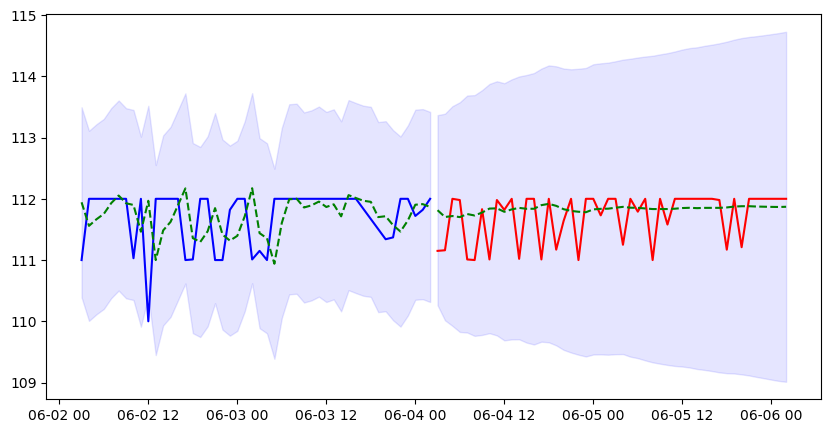

In [716]:
size_fim = 24*2
size_fore = 24*2

plt.plot(data_train[-size_fim:],'b-')
plt.fill_between(data_train.index[-size_fim:],confint_sample[-size_fim:,0],confint_sample[-size_fim:,1],color='b',alpha=0.1)
plt.plot(data_train.index[-size_fim:],fitted_vals[-size_fim:],'g--')


plt.fill_between(data_test.index[:size_fore],confint[:size_fore,0],confint[:size_fore,1],color='b',alpha=0.1)
plt.plot(data_test[:size_fore],'r-')
plt.plot(data_test.index[:size_fore],fitted[:size_fore],'g--')

plt.gcf().set_size_inches(10,5)



In [337]:
data_train[-1]

114.0

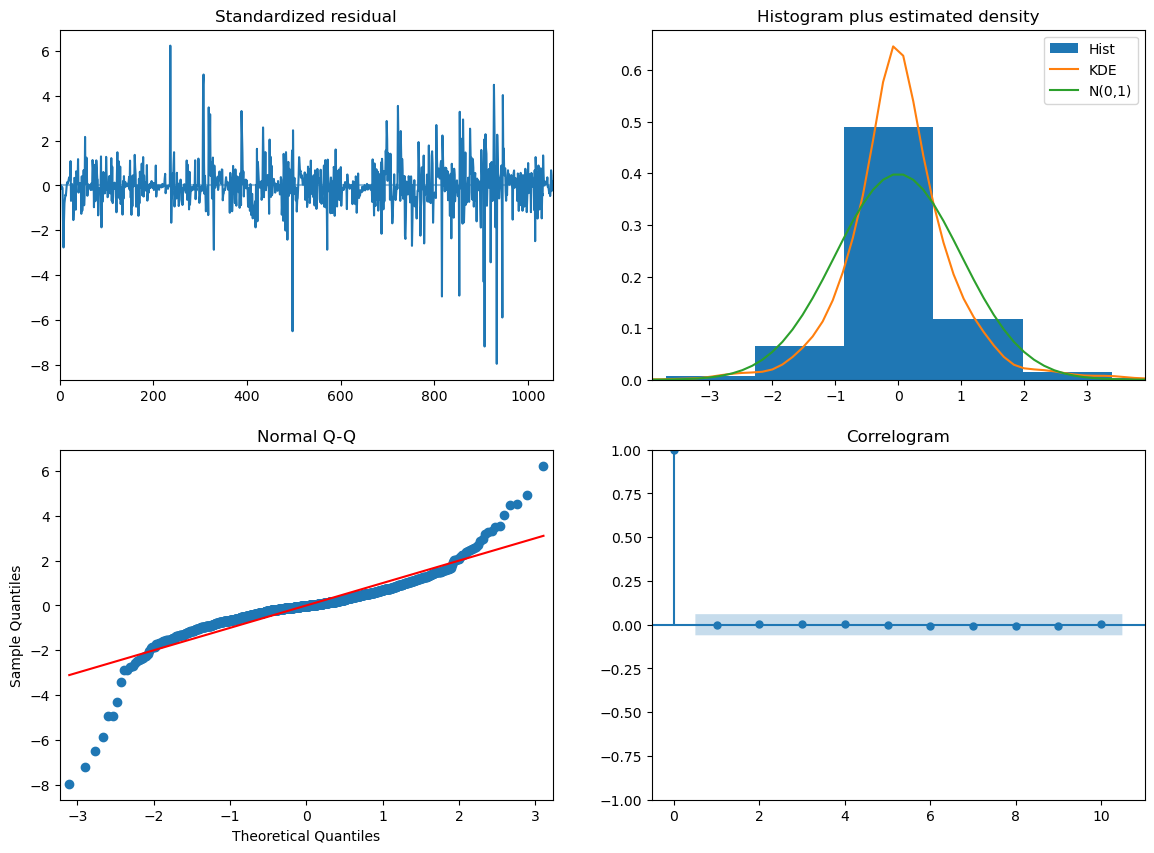

In [717]:
mod.plot_diagnostics(figsize=(14,10));

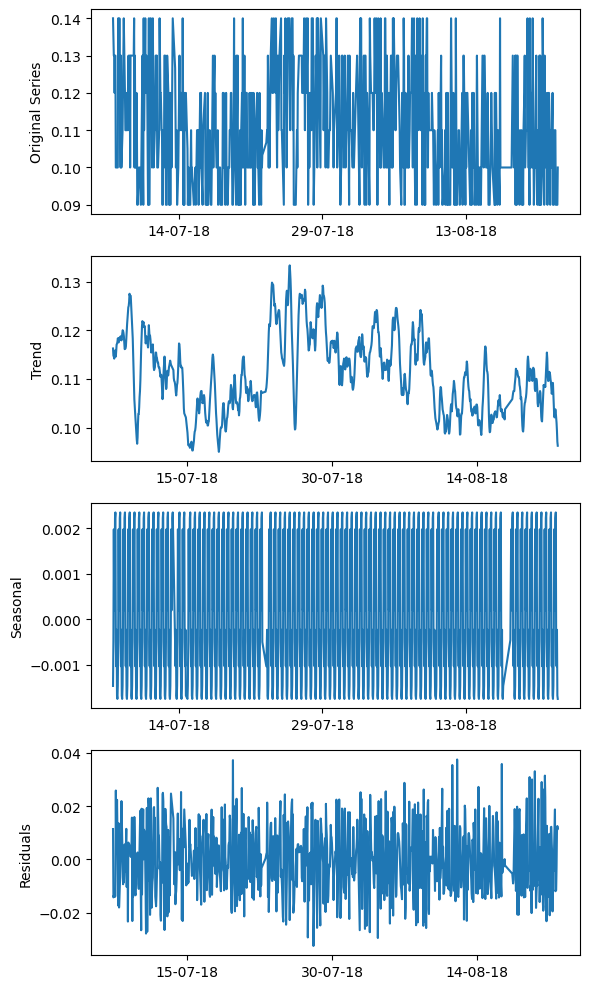

In [51]:
from statsmodels.tsa.seasonal import seasonal_decompose

for i in [12]:
    result = seasonal_decompose(data_train, model='additive', period=i)
    trend = result.trend.dropna()
    seasonal = result.seasonal.dropna()
    residual = result.resid.dropna()
    
    import matplotlib.dates as mdates
    
    # Plot the decomposed components
    plt.figure(figsize=(6,10))
     
    plt.subplot(4, 1, 1)
    plt.plot(data_train)
    plt.ylabel('Original Series')
    ax = plt.gca()
    ax.xaxis.set_major_locator(mdates.DayLocator(interval=15))
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%d-%m-%y'))
     
    plt.subplot(4, 1, 2)
    plt.plot(trend)
    plt.ylabel('Trend')
    ax = plt.gca()
    ax.xaxis.set_major_locator(mdates.DayLocator(interval=15))
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%d-%m-%y'))
     
    plt.subplot(4, 1, 3)
    plt.plot(seasonal)
    plt.ylabel('Seasonal')
    ax = plt.gca()
    ax.xaxis.set_major_locator(mdates.DayLocator(interval=15))
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%d-%m-%y'))
     
    plt.subplot(4, 1, 4)
    plt.plot(residual)
    plt.ylabel('Residuals')
    ax = plt.gca()
    ax.xaxis.set_major_locator(mdates.DayLocator(interval=15))
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%d-%m-%y'))
     
    plt.tight_layout()
    plt.draw()

    #plt.savefig(f'Figures/{i}_hours.png')


Text(0, 0.5, 'Stationary data')

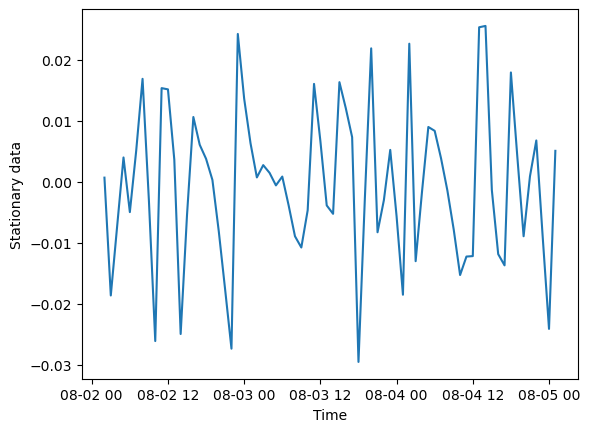

In [59]:
n = 600

x = np.linspace(0,0.002,24*3)
plt.plot(residual[n:n+(24*3)], label='Seasonal')

plt.xlabel("Time")
plt.ylabel('Stationary data')

In [248]:
def sarimax_forecast(SARIMAX_model, periods=24):
    # Forecast
    n_periods = periods
 
    forecast_df = pd.DataFrame({"month_index": pd.date_range(df.index[-1], periods=n_periods, freq='MS').month},
                               index=pd.date_range(df.index[-1] + pd.DateOffset(months=1), periods=n_periods, freq='MS'))
 
    fitted, confint = SARIMAX_model.predict(n_periods=n_periods,
                                            return_conf_int=True,
                                            exogenous=forecast_df[['month_index']])
    index_of_fc = pd.date_range(df.index[-1] + pd.DateOffset(months=1), periods=n_periods, freq='MS')
 
    # make series for plotting purpose
    fitted_series = pd.Series(fitted, index=index_of_fc)
    lower_series = pd.Series(confint[:, 0], index=index_of_fc)
    upper_series = pd.Series(confint[:, 1], index=index_of_fc)
 
    # Plot
    plt.figure(figsize=(15, 7))
    plt.plot(df["#Passengers"], color='#1f76b4')
    plt.plot(fitted_series, color='darkgreen')
    plt.fill_between(lower_series.index,
                     lower_series,
                     upper_series,
                     color='k', alpha=.15)
 
    plt.title("SARIMAX - Forecast")
    plt.show()

Text(0.5, 1.0, 'Inverse MA roots')

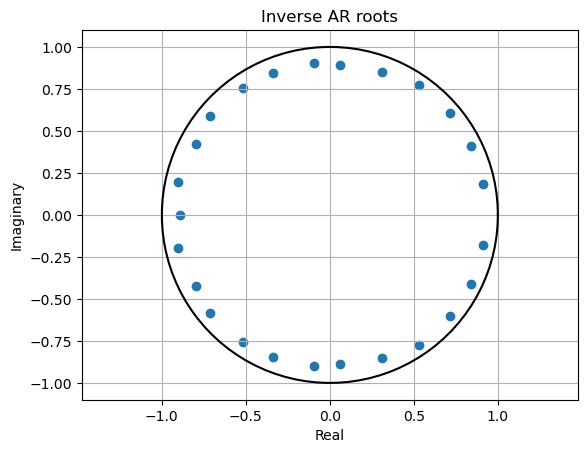

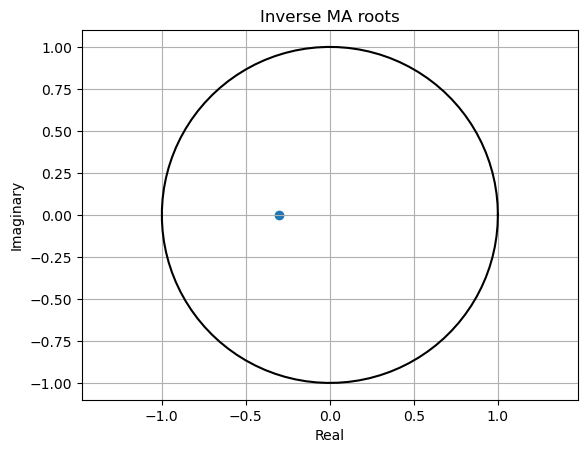

In [718]:
ar_roots = 1/res.arroots()
plt.scatter(ar_roots.real,ar_roots.imag)
theta = np.linspace(0,2*np.pi,100)
plt.plot(np.cos(theta),np.sin(theta),'k-')

ax  = plt.gca();
ax.axis('equal');
plt.xlabel("Real")
plt.ylabel("Imaginary")
plt.grid(True)
ax.set_title('Inverse AR roots')

plt.figure()

ma_roots = 1/res.maroots()
plt.scatter(ma_roots.real,ma_roots.imag)
theta = np.linspace(0,2*np.pi,100)
plt.plot(np.cos(theta),np.sin(theta),'k-')



ax  = plt.gca();
ax.axis('equal');

plt.xlabel("Real")
plt.ylabel("Imaginary")
plt.grid(True)
ax.set_title('Inverse MA roots')